# 05 — Results: the frozen test run

Dataset C, AMLH coursework. **This is the only notebook in the project that evaluates on the
test set**, and it runs after every hyperparameter in `config.py` is frozen. Nothing here
selects anything: no variant, no checkpoint, no prompt, no threshold. Every choice was made
on validation in notebooks 02–04 and is read from `config.HYPERPARAMETERS` below.

Three constraints govern this notebook:

1. **`answer` is never an inference-time input.** `data.load_test` drops the column at the
   loader, and `results.assert_no_answer_column` re-checks it at every entry point.
2. **Models are fit on `split_fit` only** — no refit on fit + val. The tested model is
   therefore the exact model that was validated, so the validation→test comparison in §7
   describes a single object.
3. **No final system is nominated.** All three arms are reported side by side, per the
   test-scope decision in `CLAUDE.md`.

Arms 2 and 3 need a GPU, so they are produced by `05_results_colab.ipynb` and land in
`artefacts/` as `arm2_test_predictions.csv` / `arm3_test_predictions.csv`. This notebook
runs standalone either way: if those files are absent it reports Arm 1 alone and says so.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from amlh import features, results
from amlh.config import ARTEFACTS_DIR, FIGURES_DIR, HYPERPARAMETERS, SEED, TRAIN_CSV, set_seed
from amlh.data import load_test

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

## 1. Freeze check

Before any test question is read, confirm every hyperparameter this run depends on is
actually frozen. A `None` here would mean a choice was never made, and the test run would
be silently inventing one — exactly what the protocol exists to prevent.

In [2]:
set_seed()

FROZEN_FIELDS = [
    "ngram_range", "min_df", "max_df", "sublinear_tf", "lemmatise",
    "index_variant", "index_scheme", "k_neighbors",
    "bert_model_name", "max_length", "learning_rate", "batch_size", "num_epochs",
    "shortlist_k", "llm_temperature", "prompt_mode", "n_shots",
    "arm3_model_name", "arm3_max_new_tokens",
]

frozen = {name: getattr(HYPERPARAMETERS, name) for name in FROZEN_FIELDS}
unset = [name for name, value in frozen.items() if value is None]
assert not unset, f"hyperparameters still unfrozen: {unset}"

print(f"SEED = {SEED}")
for name, value in frozen.items():
    print(f"  {name:24s} = {value!r}")
print(f"\nall {len(frozen)} hyperparameters frozen")

SEED = 44
  ngram_range              = (1, 2)
  min_df                   = 1
  max_df                   = 1.0
  sublinear_tf             = False
  lemmatise                = False
  index_variant            = 'QLAD'
  index_scheme             = 'class_blob'
  k_neighbors              = 1
  bert_model_name          = 'emilyalsentzer/Bio_ClinicalBERT'
  max_length               = 48
  learning_rate            = 2e-05
  batch_size               = 16
  num_epochs               = 15
  shortlist_k              = 20
  llm_temperature          = 0.0
  prompt_mode              = 'zero_shot'
  n_shots                  = 2
  arm3_model_name          = 'microsoft/MediPhi-Guidelines'
  arm3_max_new_tokens      = 20

all 19 hyperparameters frozen


## 2. Load the frozen inputs

`split_fit` is the 8,691-row training half — *not* the full training set. `load_test`
returns the 200 test items with `answer` already dropped.

In [3]:
fit = pd.read_csv(ARTEFACTS_DIR / "split_fit.csv")
test = load_test()

results.assert_no_answer_column(test)
print(f"fit  = {len(fit):5d} rows, {fit.disease.nunique()} classes")
print(f"test = {len(test):5d} rows, {test.disease.nunique()} classes")
print(f"test columns: {list(test.columns)}  <- no `answer`")

unseen = set(test.disease) - set(fit.disease)
print(f"test classes absent from split_fit: {len(unseen)}")

fit  =  8691 rows, 906 classes
test =   200 rows, 102 classes
test columns: ['question', 'disease', 'reference_url']  <- no `answer`
test classes absent from split_fit: 0


## 3. Arm 1 — TF-IDF + k-NN retrieval on test

`require_doc_coverage` is the guard added after the 2026-08-23 incident: the frozen
`index_variant` is `QLAD`, whose `D` component is the NHS document text, and before the
guard existed a missing document directory silently degraded QLAD to QLA. It raises rather
than degrading.

The ranking is produced by the same `arm1_experiments.frozen_ranking` code path the
validation grid used, at the same hyperparameters, so the test and validation numbers
describe one system rather than two implementations that happen to agree.

In [4]:
coverage = features.require_doc_coverage(fit.disease.unique())
print(f"doc coverage: {coverage}")

doc coverage: {'n_total': 906, 'n_found': 906, 'missing': []}


In [5]:
set_seed()

arm1_test = results.build_test_predictions(fit, test, HYPERPARAMETERS)
arm1_test.to_csv(ARTEFACTS_DIR / "arm1_test_predictions.csv", index=False)

accuracy = (arm1_test["pred"] == arm1_test["gold"]).mean()
print(f"Arm 1 test accuracy: {accuracy:.4f} over {len(arm1_test)} items")
print(f"written to arm1_test_predictions.csv with top_1..top_{results.SHORTLIST_DEPTH}")
arm1_test[["question", "gold", "pred", "top_sim"]].head()

Arm 1 test accuracy: 0.7650 over 200 items
written to arm1_test_predictions.csv with top_1..top_20


,question,gold,pred,top_sim
0,How is IVA diagnosed?,isovaleric_acidaemia,isovaleric_acidaemia,0.355787
1,How can one be exposed to asbestos?,asbestosis,asbestosis,0.256116
2,What is a stoma nurse?,colostomy,ileostomy,0.192215
3,What are the symptoms of TB?,tuberculosis_tb,tuberculosis_tb,0.525441
4,How is PBC diagnosed?,primary_biliary_cholangitis_pbc,primary_biliary_cholangitis_pbc,0.550686


## 4. Collect whatever arms have been produced

`load_available_arms` returns only the files that exist. If the Colab half has not been run
yet this reports Arm 1 alone rather than raising — the notebook has to survive a kernel
restart on a machine that never saw a GPU.

In [6]:
frames = results.load_available_arms()
missing = [arm for arm in results.TEST_PREDICTION_FILES if arm not in frames]

print("available:", list(frames))
if missing:
    print(f"MISSING: {missing} -- run 05_results_colab.ipynb and copy its artefacts in.")
    print("Sections below will report only the arms present.")
else:
    print("all three arms present")

gold = results.assert_query_aligned(frames)
print(f"\nquery-aligned on {len(gold)} test items")

available: ['arm1_tfidf_knn', 'arm2_bio_clinicalbert', 'arm3_llm_rerank']
all three arms present

query-aligned on 200 test items


## 5. Headline test results

Accuracy is the headline metric the brief specifies, with a percentile bootstrap 95% CI over
resampled items. Top-5, macro-F1 and MRR ride along for the error analysis in §8 — they
explain *why* accuracy is capped and are not being promoted to headline status.

In [7]:
test_scores = results.score_arms(frames)
test_scores.to_csv(ARTEFACTS_DIR / "arm_test_comparison.csv", index=False)
test_scores

,arm,label,n,accuracy,ci_low,ci_high,macro_f1,acc_at_5,mrr
0,arm1_tfidf_knn,Arm 1 — TF-IDF + k-NN retrieval,200,0.765,0.705,0.82,0.563030,0.925,0.839067
1,arm2_bio_clinicalbert,Arm 2 — Bio_ClinicalBERT fine-tune,200,0.615,0.545,0.68,0.353655,0.735,0.665012
2,arm3_llm_rerank,Arm 3 — shortlist + MediPhi selection,200,0.720,0.660,0.78,0.494322,NaN,NaN


## 6. Pairwise McNemar on test

Every arm answers the same 200 questions, so the comparisons are paired and the items two
arms agree on carry no evidence about which is better. That is why a difference of two
accuracies is not judged against a single-proportion SE. All pairs are reported because no
final system is nominated — each comparison is a result, not a step toward one.

In [8]:
test_mcnemar = results.pairwise_mcnemar(frames)
test_mcnemar.to_csv(ARTEFACTS_DIR / "arm_test_mcnemar.csv", index=False)

for row in test_mcnemar.itertuples(index=False):
    verdict = "RESOLVED" if row.p_value < 0.05 else "UNRESOLVED"
    print(f"{row.system_a:24s} vs {row.system_b:24s} p = {row.p_value:.4g}  -> {verdict}")
test_mcnemar

arm1_tfidf_knn           vs arm2_bio_clinicalbert    p = 5.3e-06  -> RESOLVED
arm1_tfidf_knn           vs arm3_llm_rerank          p = 0.1496  -> UNRESOLVED
arm2_bio_clinicalbert    vs arm3_llm_rerank          p = 0.001914  -> RESOLVED


,system_a,system_b,n,accuracy_a,accuracy_b,accuracy_diff,only_a_correct,only_b_correct,n_discordant,p_value
0,arm1_tfidf_knn,arm2_bio_clinicalbert,200,0.765,0.615,0.150,37,7,44,0.000005
1,arm1_tfidf_knn,arm3_llm_rerank,200,0.765,0.720,0.045,20,11,31,0.149613
2,arm2_bio_clinicalbert,arm3_llm_rerank,200,0.615,0.720,-0.105,11,32,43,0.001914


## 7. Validation → test optimism

`CLAUDE.md` records that the single stratified hold-out over-estimates test accuracy by
roughly 35pp for Arm 1, because a held-out question is a phrasing sibling of those left in
training while a test question is not. This measures that gap **per arm** rather than
assuming it is uniform — a retrieval arm and a fine-tuned encoder need not be optimistic by
the same amount, and if they are not, that is itself a result.

This is a diagnostic of the hold-out protocol computed after the test run. It selects nothing.

In [9]:
gap = results.validation_test_gap(test_scores)
gap.to_csv(ARTEFACTS_DIR / "validation_test_gap.csv", index=False)
gap

,arm,label,test_accuracy,val_accuracy,optimism
0,arm1_tfidf_knn,Arm 1 — TF-IDF + k-NN retrieval,0.765,0.85,0.085
1,arm2_bio_clinicalbert,Arm 2 — Bio_ClinicalBERT fine-tune,0.615,0.85,0.235
2,arm3_llm_rerank,Arm 3 — shortlist + MediPhi selection,0.720,0.72,0.000


## 8. Error analysis

### 8a. Most frequent confusions

`same_family` flags whether gold and prediction share a label prefix; `family_error_possible`
flags whether that row's gold label had **any** sibling in the 906-label space to be confused
with. Both are needed: a `same_family` column of all-False means nothing on its own, because
it cannot be told apart from a set of gold labels that had no siblings in the first place.

Rates belong in §8b, not here — this frame is truncated to the ten most frequent pairs and is
not a basis for one.

In [10]:
label_space = pd.read_csv(TRAIN_CSV)["disease"].unique()

for arm, frame in frames.items():
    pairs = results.confusion_pairs(frame, top_n=10, label_space=label_space)
    print()
    print(f"=== {results.ARM_LABELS.get(arm, arm)} - top confusions ===")
    print(pairs.to_string(index=False))
    pairs.to_csv(ARTEFACTS_DIR / f"{arm}_test_confusions.csv", index=False)


=== Arm 1 — TF-IDF + k-NN retrieval - top confusions ===
                      gold                                                                      pred  n  same_family  family_error_possible
disorders_of_consciousness                                                               brain_death  3        False                  False
                 colostomy                                                                 ileostomy  2        False                  False
          craniosynostosis                                               plagiocephaly_brachycephaly  2        False                  False
                  diabetes                                                      diabetic_retinopathy  2        False                  False
                 achalasia                          baby_newborn_screening_blood_spot_screening_faqs  1        False                  False
             psychotherapy                                                               counselling  

### 8b. Family-internal error share — conditioned on being possible

The headline question is whether residual error is *fine-grained* (confusing two conditions in
the same family) or *coarse* (missing the topic entirely). An unconditioned share cannot answer
it: a gold label whose prefix family has only one member **cannot** be confused with a sibling,
so it contributes a guaranteed zero to the numerator while still inflating the denominator.

That distinction decides the reading here. On validation 88 of 200 items have a gold label in a
multi-member family; on test only 18 do. So the unconditioned figure reads 0% for every arm on
test while the conditioned denominator is a *single error* — and reporting that as "the error
mode changed between splits" would dress up a fact about the two samples' class composition as
a fact about the models.

`family_error_summary` reports the conditioned denominator alongside the count and returns
`None` rather than `0.0` when nothing was possible. **Read `n_family_error_possible` before the
share.** On test it is too small to support a rate, which is why §3.3 of the report quotes this
metric on validation only.

In [11]:
rows = [{"arm": arm, **results.family_error_summary(frame, label_space)} for arm, frame in frames.items()]
family_errors = pd.DataFrame(rows)
family_errors.to_csv(ARTEFACTS_DIR / "test_family_error_share.csv", index=False)

# The same measurement on validation, where the denominator does support a rate. This is the
# comparison the report needs, and it is the *denominator* that differs between the splits.
val_frames = {
    "arm1_tfidf_knn": pd.read_csv(ARTEFACTS_DIR / "arm1_val_predictions.csv"),
    "arm2_bio_clinicalbert": pd.read_csv(ARTEFACTS_DIR / "arm2_val_predictions.csv"),
}
val_family_errors = pd.DataFrame(
    [{"arm": a, **results.family_error_summary(f, label_space)} for a, f in val_frames.items()]
)
val_family_errors.to_csv(ARTEFACTS_DIR / "val_family_error_share.csv", index=False)

print("TEST - denominator too small to support a rate:")
print(family_errors.to_string(index=False))
print()
print("VALIDATION - denominator supports a rate:")
print(val_family_errors.to_string(index=False))

TEST - denominator too small to support a rate:
                  arm  n_errors  n_family_error_possible  n_within_family  within_family_share
       arm1_tfidf_knn        47                        1                0                  0.0
arm2_bio_clinicalbert        77                        4                0                  0.0
      arm3_llm_rerank        56                        1                0                  0.0

VALIDATION - denominator supports a rate:
                  arm  n_errors  n_family_error_possible  n_within_family  within_family_share
       arm1_tfidf_knn        30                       25               18              0.72000
arm2_bio_clinicalbert        30                       21               10              0.47619


### 8c. What the LLM actually did to the shortlist

Arm 3's headline accuracy is a blend of three populations that behave completely
differently. Reporting it undivided makes the arm look uniformly weak rather than weak in
one specific, diagnosable way. `arm1_accuracy` on each stratum is the counterfactual — what
the shortlist alone would have scored on those same items.

On validation this decomposition showed every net loss came from active re-ranking, with an
intervention precision of 6/50. This checks whether the pattern holds on test.

In [12]:
if "arm3_llm_rerank" in frames:
    decomposition = results.rerank_decomposition(frames["arm3_llm_rerank"])
    decomposition.to_csv(ARTEFACTS_DIR / "arm3_test_decomposition.csv", index=False)
    display(decomposition)
else:
    print("Arm 3 test predictions absent -- run 05_results_colab.ipynb first.")

interventions: 38 | rescued 11 | broke 20 | precision 0.289


,stratum,n,share,arm3_accuracy,arm1_accuracy,accuracy_delta
0,kept_rank_1,120,0.60,0.958333,0.958333,0.000000
1,fell_back,42,0.21,0.428571,0.428571,0.000000
2,moved_off_rank_1,38,0.19,0.289474,0.526316,-0.236842


### 8d. Worked examples

The brief asks for examples of correct and incorrect predictions per method. Sampled with
the project seed so the report's examples are stable across reruns.

In [13]:
examples = results.worked_examples(frames, n=4)
examples.to_csv(ARTEFACTS_DIR / "test_worked_examples.csv", index=False)
examples

,arm,outcome,question,gold,pred
0,arm1_tfidf_knn,correct,What are the things one can do to help recognize people ...,face_blindness,face_blindness
1,arm1_tfidf_knn,correct,What is the treatment for HHT?,hereditary_haemorrahagic_telangiectasia,hereditary_haemorrahagic_telangiectasia
2,arm1_tfidf_knn,correct,What are the treatments for MDS?,myelodysplasia,myelodysplasia
3,arm1_tfidf_knn,correct,What should I do to protect a blister from getting infec...,blisters,blisters
4,arm1_tfidf_knn,incorrect,How does everolimus work?,neuroendocrine_tumours,social_care_and_support_guide_money_work_and_benefits_wo...
5,arm1_tfidf_knn,incorrect,What should I do if someone has a seizure?,epilepsy,what_to_do_if_someone_has_a_seizure_fit
6,arm1_tfidf_knn,incorrect,What is counselling for depression?,psychotherapy,counselling
7,arm1_tfidf_knn,incorrect,What is the diabetic eye screening?,diabetes,diabetic_retinopathy
8,arm2_bio_clinicalbert,correct,How is GA1 diagnosed in babies?,glutaric_aciduria,glutaric_aciduria
9,arm2_bio_clinicalbert,correct,What should I do if I accidentally take an extra dose of...,antibiotics,antibiotics


### 9a. Figures F4 and F5 — workflow diagrams

Required by the brief, one per method. Drawn by `amlh.diagrams`, which reads every
hyperparameter it prints from `config.HYPERPARAMETERS` rather than from hard-coded text, so a
diagram cannot silently drift out of step with the frozen configuration.

In [14]:
from amlh import diagrams

diagrams.draw_arm1_workflow()
diagrams.draw_arms23_workflow()
plt.close("all")

wrote D:\UCL\Academic\AMLH\Assignment\workstation\figures\fig4_arm1_workflow.png


wrote D:\UCL\Academic\AMLH\Assignment\workstation\figures\fig5_arms23_workflow.png


### 9b. Most frequent confusions (report Figure 6)

One panel per arm, over the pairs each arm confuses most often on test. `family_error_possible`
from §8a is shown as a marker: a bar is annotated only where the gold label actually had a
sibling to be confused with, so the reader is not invited to infer a fine-grained failure from a
pair that could never have been one.

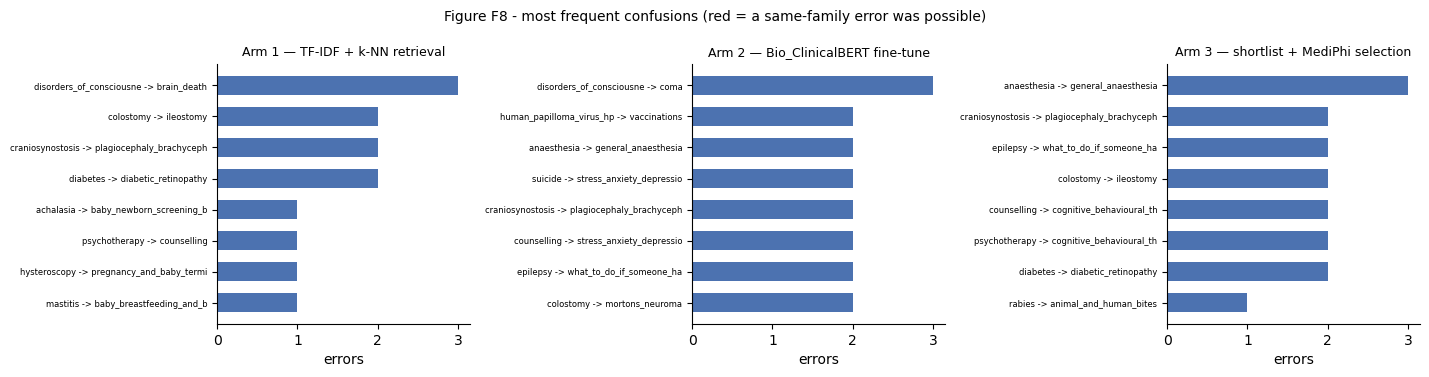

In [15]:
fig, axes = plt.subplots(1, len(frames), figsize=(4.8 * len(frames), 3.8))
axes = axes if len(frames) > 1 else [axes]

for ax, (arm, frame) in zip(axes, frames.items()):
    pairs = results.confusion_pairs(frame, top_n=8, label_space=label_space)
    labels = [f"{g[:24]} -> {p[:24]}" for g, p in zip(pairs["gold"], pairs["pred"])]
    colours = ["#a8422f" if poss else "#4c72b0" for poss in pairs["family_error_possible"]]
    y = range(len(pairs))
    ax.barh(list(y), pairs["n"], color=colours, height=0.6)
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels, fontsize=6)
    ax.invert_yaxis()
    ax.set_xlabel("errors")
    ax.set_title(results.ARM_LABELS.get(arm, arm), fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.get_major_locator().set_params(integer=True)

fig.suptitle("Most frequent test-set confusions, one panel per arm", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig8_confusions.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Figure — test accuracy with bootstrap CIs

Figure F9 for the report. Error bars are the percentile bootstrap 95% CIs from §5, not
±1 SE, so the visual comparison matches the interval actually quoted in the text.

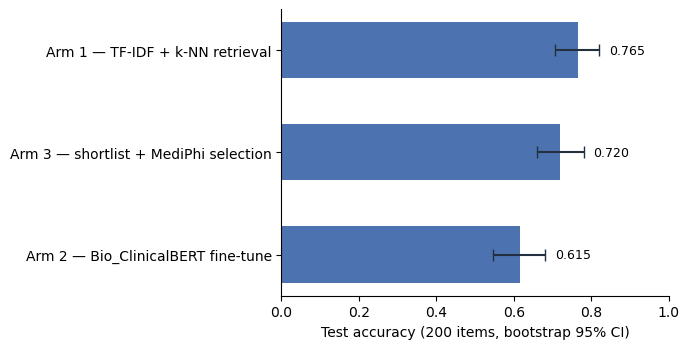

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.6))

order = test_scores.sort_values("accuracy", ascending=True)
y = range(len(order))
lower = order["accuracy"] - order["ci_low"]
upper = order["ci_high"] - order["accuracy"]

ax.barh(list(y), order["accuracy"], color="#4c72b0", height=0.55)
ax.errorbar(order["accuracy"], list(y), xerr=[lower, upper], fmt="none", ecolor="#22303f", capsize=4)
ax.set_yticks(list(y))
ax.set_yticklabels(order["label"])
ax.set_xlabel("Test accuracy (200 items, bootstrap 95% CI)")
ax.set_xlim(0, 1)
# Label sits clear of the upper CI whisker, not on top of it.
for i, value, hi in zip(y, order["accuracy"], order["ci_high"]):
    ax.text(hi + 0.025, i, f"{value:.3f}", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig9_test_accuracy.png", dpi=200)
plt.show()

## 10. Artefacts written

Everything the report reads from this notebook, in one place.

In [17]:
written = [
    "arm1_test_predictions.csv",
    "arm_test_comparison.csv",
    "arm_test_mcnemar.csv",
    "validation_test_gap.csv",
    "test_family_error_share.csv",
    "val_family_error_share.csv",
    "test_worked_examples.csv",
]
written += [f"{arm}_test_confusions.csv" for arm in frames]
if "arm3_llm_rerank" in frames:
    written.append("arm3_test_decomposition.csv")

for name in written:
    path = ARTEFACTS_DIR / name
    print(f"  {'ok ' if path.exists() else 'MISSING'} {name}")

print()
for name in ("fig4_arm1_workflow.png", "fig5_arms23_workflow.png",
             "fig8_confusions.png", "fig9_test_accuracy.png"):
    print(f"  {'ok ' if (FIGURES_DIR / name).exists() else 'MISSING'} {name}")

  ok  arm1_test_predictions.csv
  ok  arm_test_comparison.csv
  ok  arm_test_mcnemar.csv
  ok  validation_test_gap.csv
  ok  test_family_error_share.csv
  ok  val_family_error_share.csv
  ok  test_worked_examples.csv
  ok  arm1_tfidf_knn_test_confusions.csv
  ok  arm2_bio_clinicalbert_test_confusions.csv
  ok  arm3_llm_rerank_test_confusions.csv
  ok  arm3_test_decomposition.csv

  ok  fig4_arm1_workflow.png
  ok  fig5_arms23_workflow.png
  ok  fig8_confusions.png
  ok  fig9_test_accuracy.png
